In [1]:
import os
import uuid
from langgraph.checkpoint.memory import MemorySaver
from langgraph.constants import START,END
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from typing import Annotated

In [21]:
class InputState(dict):
    user_input: str

class OutputState(dict):
    graph_output: str

class OverallState(dict):
    foo: str
    user_input: str
    graph_output: str
    bar:str

class PrivateState(dict):
    bar: str

def node_1(state: InputState) -> OverallState:
    print("node1",state)
    return {"foo": state["user_input"] + " name"}

def node_2(state: OverallState) -> PrivateState:
    print("node2",state)
    return {"bar": state["foo"] + " is"}

def node_3(state: PrivateState) -> OutputState:
    # Read from PrivateState, write to OutputState
    print("node3",state)

    return {"graph_output": state["bar"] + " Lance"}

builder = StateGraph(OverallState,input=InputState,output=OutputState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", "node_3")
builder.add_edge("node_3", END)

graph = builder.compile()
reults=graph.invoke({"user_input":"My"})


node1 {'user_input': 'My'}
node2 {'foo': 'My name', 'user_input': 'My'}
node3 {'bar': 'My name is'}


In [5]:
reults

{'graph_output': 'My name is Lance'}

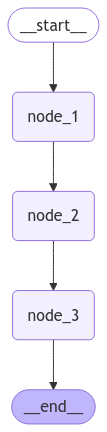

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [22]:
from typing import Annotated
from typing_extensions import TypedDict
from operator import add

class State(TypedDict):
    foo: int
    bar: Annotated[list[str], add]

In this example, we've used the Annotated type to specify a reducer function (operator.add) for the second key (bar). Note that the first key remains unchanged. Let's assume the input to the graph is {"foo": 1, "bar": ["hi"]}. Let's then assume the first Node returns {"foo": 2}. This is treated as an update to the state. Notice that the Node does not need to return the whole State schema - just an update. After applying this update, the State would then be {"foo": 2, "bar": ["hi"]}. If the second node returns {"bar": ["bye"]} then the State would then be {"foo": 2, "bar": ["hi", "bye"]}. Notice here that the bar key is updated by adding the two lists together.


In [55]:
def add_list(a,b):
    print("a",a)
    print("b",b)

    return a+b

In [ ]:
class State(TypedDict):
    a:Annotated[list[str],add_list]
def node1(state:State):
    return {"a":["hello"]}
def node2(state:State):
    return {"a":["bye"]}
def node3(state:State):
    return {"a":["sk"]}
def node4(state:State):
    return {"a":["yo"]}
def node5(state:State):
    return {"a":["haah"]}
builder=StateGraph(State)
builder.add_node("node1",node1)
builder.add_node("node2",node2)
builder.add_node("node3",node3)
builder.add_node("node4",node4)
builder.add_node("node5",node5)
builder.add_edge(START,"node1")
builder.add_edge("node1","node2")
builder.add_edge("node2","node3")
builder.add_edge("node3","node4")
builder.add_edge("node4","node5")
builder.add_edge("node5",END)
builder.add_node("node69",node1)
graph=builder.compile()


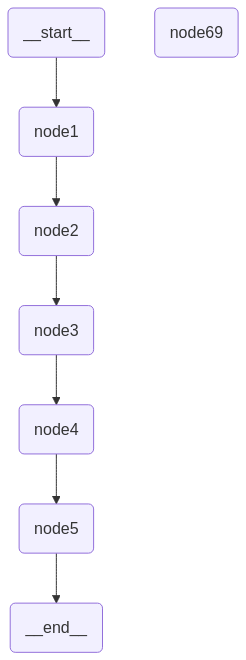

In [58]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [59]:
graph.invoke({"a":["start"]})


a []
b ['start']
a ['start']
b ['hello']
a ['start', 'hello']
b ['bye']
a ['start', 'hello', 'bye']
b ['sk']
a ['start', 'hello', 'bye', 'sk']
b ['yo']
a ['start', 'hello', 'bye', 'sk', 'yo']
b ['haah']


{'a': ['start', 'hello', 'bye', 'sk', 'yo', 'haah']}

In [61]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict




In [ ]:
from langchain_core.runnables import RunnableConfig
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def node1(state:State,config: RunnableConfig):
    return {"messages":[{"role":"human","content":"Hi buddy"}]}
def node2(state:State,config: RunnableConfig):
    return {"messages":[{"role":"assistant","content":"hi human"}]}
"""
 role can Be
    ai
    human
    tool
    function
    system

"""
builder=StateGraph(State)
builder.add_node("node1",node1)
builder.add_node("node2",node2)

builder.add_edge(START,"node1")
builder.add_edge("node1","node2")
builder.add_edge("node2",END)
graph=builder.compile()

In [103]:
graph.invoke({"message":[]})

node1 {'__pregel_task_id': '942eba54-b5ca-519a-6db3-3f25be93f014', '__pregel_send': functools.partial(<function local_write at 0x000001F7963E3920>, <built-in method extend of collections.deque object at 0x000001F7C368AA70>, ('__start__', 'node1', 'node2')), '__pregel_read': functools.partial(<function local_read at 0x000001F7963E3880>, 1, {'v': 1, 'ts': '2025-03-29T22:18:55.383216+00:00', 'id': '1f00cebc-d8be-6ae8-8000-4309977ced07', 'channel_values': {'start:node1': '__start__'}, 'channel_versions': {'__start__': 2, 'start:node1': 2}, 'versions_seen': {'__input__': {}, '__start__': {'__start__': 1}}, 'pending_sends': []}, {'messages': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x000001F7C35EEA80>, '__start__': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x000001F7C3144C80>, 'node1': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x000001F7C3144580>, 'branch:to:node1': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x000001F

{'messages': [HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='5fba97d1-09a3-4db9-b693-225ac565325f'),
  AIMessage(content='hi human', additional_kwargs={}, response_metadata={}, id='8827866d-f917-47e4-8ea8-8379578e6df8')]}

In [119]:
from langchain_core.runnables import RunnableConfig
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    vis:bool

def node1(state:State,config: RunnableConfig):
    return {"messages":[{"role":"human","content":"Hi buddy"}]}
def node2(state:State,config: RunnableConfig):

    return {"messages":[{"role":"assistant","content":"hi human"}],"vis":False}
"""
 role can Be
    ai
    human
    tool
    function
    system

"""

def func(state:State):
    print("state=",state)
    return state["vis"]

builder=StateGraph(State)
builder.add_node("node1",node1)
builder.add_node("node2",node2)

builder.add_edge(START,"node1")
builder.add_conditional_edges("node1",func,{True:"node2",False:END})
builder.add_edge("node2","node1")

graph=builder.compile()
graph.invoke({"message":[],"vis":True})

state= {'messages': [HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='e4f9d9c7-795f-4b95-b771-2452342e14c0')], 'vis': True}
state= {'messages': [HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='f88b3873-17be-4672-ba29-cd6c87bf2b44'), AIMessage(content='hi human', additional_kwargs={}, response_metadata={}, id='76d28d69-a3e9-46b0-a1eb-77f3dbdbe0ef'), HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='b441e89d-7369-471e-bf28-16a9861c16e9')], 'vis': False}


{'messages': [HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='f88b3873-17be-4672-ba29-cd6c87bf2b44'),
  AIMessage(content='hi human', additional_kwargs={}, response_metadata={}, id='76d28d69-a3e9-46b0-a1eb-77f3dbdbe0ef'),
  HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='fbb667af-e242-4b98-9d67-cc267aa52b71')],
 'vis': False}

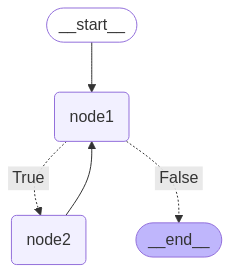

In [118]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [137]:
from langchain_core.runnables import RunnableConfig
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    vis:bool

def node1(state:State,config: RunnableConfig):
    return {"messages":[{"role":"human","content":"Hi buddy"}]}
def node2(state:State,config: RunnableConfig):

    return {"messages":[{"role":"assistant","content":"hi human"}],"vis":False}
"""
 role can Be
    ai
    human
    tool
    function
    system

"""

def func(state:State):
    print("state=",state)
    if(state["vis"]==True):
        return "tool"
    else :
        return END

builder=StateGraph(State)
builder.add_node("node1",node1)
builder.add_node("node2",node2)

builder.add_edge(START,"node1")
builder.add_conditional_edges("node1",func,{"tool":"node2",END:END})
builder.add_edge("node2","node1")

graph=builder.compile()
result=graph.invoke({"message":[],"vis":True})

state= {'messages': [HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='d7a3b745-5bd1-46a9-bf56-82339798e7ad')], 'vis': True}
state= {'messages': [HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='1a09fd22-948b-4548-8813-49ab73f2045b'), AIMessage(content='hi human', additional_kwargs={}, response_metadata={}, id='855e84b2-5403-4378-a05b-f545cabc0975'), HumanMessage(content='Hi buddy', additional_kwargs={}, response_metadata={}, id='ec0d0d52-31e4-4d67-9772-7df65b08ad3f')], 'vis': False}


In [143]:
result["messages"][-2].tool_calls

[]

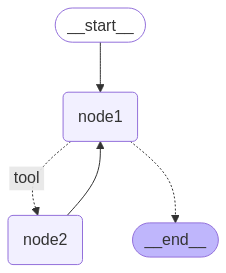

In [124]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [134]:
def hmm(a,b):
    print("a",a)
    print("b",b)
    return a+b
from langgraph.types import Send
class State(TypedDict):
    a:Annotated[list[str],hmm]

class Joke(TypedDict):
    sub:str
def node1(state:State)->State:
    return {"a":["joke1","joke2","joke3"]}
def jokeLLM(state:Joke)->State:
    print(state)
    return {"a":[state["sub"]]}


def func(state:State)->Joke:
    return [Send("jokeLLM",{"sub":s}) for s in state["a"]]


builder=StateGraph(State)
builder.add_node("node1",node1)
builder.add_node("jokeLLM",jokeLLM)

builder.add_edge(START,"node1")
builder.add_conditional_edges("node1",func)
builder.add_edge("jokeLLM",END)

graph=builder.compile()

graph.invoke({"a":[]})


a []
b []
a []
b ['joke1', 'joke2', 'joke3']
a []
b ['joke1', 'joke2', 'joke3']
{'sub': 'joke1'}
{'sub': 'joke2'}
{'sub': 'joke3'}
a ['joke1', 'joke2', 'joke3']
b ['joke1']
a ['joke1', 'joke2', 'joke3', 'joke1']
b ['joke2']
a ['joke1', 'joke2', 'joke3', 'joke1', 'joke2']
b ['joke3']


{'a': ['joke1', 'joke2', 'joke3', 'joke1', 'joke2', 'joke3']}

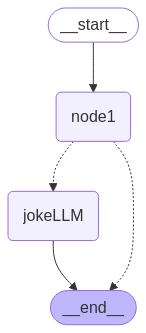

In [135]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


# command 
It can be useful to combine control flow (edges) and state updates (nodes). For example, you might want to BOTH perform state updates AND decide which node to go to next in the SAME node. LangGraph provides a way to do so by returning a Command object from node functions:

In [ ]:
def my_node(state: State):
    return Command(
        # state update
        update={"foo": "bar"},
        # control flow
        goto="my_other_node"
    )


# Navigating to a node in a parent graph
If you are using subgraphs, you might want to navigate from a node within a subgraph to a different subgraph (i.e. a different node in the parent graph). To do so, you can specify graph=Command.PARENT in Command:



In [ ]:
def my_node(state: State) -> Command[Literal["other_subgraph"]]:
    return Command(
        update={"foo": "bar"},
        goto="other_subgraph",  # where `other_subgraph` is a node in the parent graph
        graph=Command.PARENT
    )

# Using inside tools 
A common use case is updating graph state from inside a tool. For example, in a customer support application you might want to look up customer information based on their account number or ID in the beginning of the conversation. To update the graph state from the tool, you can return Command(update={"my_custom_key": "foo", "messages": [...]}) from the tool:

In [ ]:
@tool
def lookup_user_info(tool_call_id: Annotated[str, InjectedToolCallId], config: RunnableConfig):
    """Use this to look up user information to better assist them with their questions."""
    user_info = get_user_info(config.get("configurable", {}).get("user_id"))
    return Command(
        update={
            # update the state keys
            "user_info": user_info,
            # update the message history
            "messages": [ToolMessage("Successfully looked up user information", tool_call_id=tool_call_id)]
        }
    )

In [ ]:
"""Configuration¶
When creating a graph, you can also mark that certain parts of the graph are configurable. This is commonly done to enable easily switching between models or system prompts. This allows you to create a single "cognitive architecture" (the graph) but have multiple different instance of it.

You can optionally specify a config_schema when creating a graph."""


class ConfigSchema(TypedDict):
    llm: str

graph = StateGraph(State, config_schema=ConfigSchema)
"""You can then pass this configuration into the graph using the configurable config field.
"""

config = {"configurable": {"llm": "anthropic"}}

graph.invoke(inputs, config=config)
""""You can then access and use this configuration inside a node:
""""

def node_a(state, config):
    llm_type = config.get("configurable", {}).get("llm", "openai")
    llm = get_llm(llm_type)
    ...

"""Recursion Limit¶
The recursion limit sets the maximum number of super-steps the graph can execute during a single execution. Once the limit is reached, LangGraph will raise GraphRecursionError. By default this value is set to 25 steps. The recursion limit can be set on any graph at runtime, and is passed to .invoke/.stream via the config dictionary. Importantly, recursion_limit is a standalone config key and should not be passed inside the configurable key as all other user-defined configuration. See the example below:
"""

graph.invoke(inputs, config={"recursion_limit": 5, "configurable":{"llm": "anthropic"}})

In [ ]:
"""Subgraphs¶
A subgraph is a graph that is used as a node in another graph. This is nothing more than the age-old concept of encapsulation, applied to LangGraph. Some reasons for using subgraphs are:

building multi-agent systems

when you want to reuse a set of nodes in multiple graphs, which maybe share some state, you can define them once in a subgraph and then use them in multiple parent graphs

when you want different teams to work on different parts of the graph independently, you can define each part as a subgraph, and as long as the subgraph interface (the input and output schemas) is respected, the parent graph can be built without knowing any details of the subgraph

There are two ways to add subgraphs to a parent graph:

add a node with the compiled subgraph: this is useful when the parent graph and the subgraph share state keys and you don't need to transform state on the way in or out"""

builder.add_node("subgraph", subgraph_builder.compile())









"""add a node with a function that invokes the subgraph: this is useful when the parent graph and the subgraph have different state schemas and you need to transform state before or after calling the subgraph
"""
subgraph = subgraph_builder.compile()

def call_subgraph(state: State):
    return subgraph.invoke({"subgraph_key": state["parent_key"]})

builder.add_node("subgraph", call_subgraph)


In [150]:
class State(TypedDict):
    a:Annotated[list[str],add_list]
def node1(state:State):
    return {"a":["hello"]}
def node2(state:State):
    return {"a":["bye"]}
def node3(state:State):
    return {"a":["sk"]}
def node4(state:State):
    return {"a":["yo"]}
def node5(state:State):
    return {"a":["haah"]}


builder=StateGraph(State).add_sequence([node1,node2,node3,node4,node5])

builder.set_entry_point("node1")
builder.set_finish_point("node5")
graph=builder.compile()

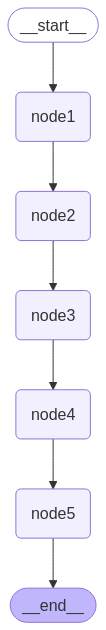

In [151]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass